# 🎓 Data-Driven Unsupervised Clustering of Online Learner Behaviour (Peach et al., 2019)
### *Replicating the Multiscale Temporal DTW-RMST-Louvain Pipeline Using Pure Raw Time-Series Clicks*

This notebook provides a complete, high-fidelity replication of the mathematical framework introduced in the **npj Science of Learning** paper by **Peach et al. (2019)**. 

Unlike aggregate features (e.g., total clicks, mean scores), this pipeline clusters students using **raw weekly engagement sequences** (clicks per week over 34 weeks). This captures *how* and *when* students engage over time, uncovering distinct behavioral strategies directly from the time-series sequences.

---

## 📐 Mathematical Formulation
The pipeline consists of three core phases:
1. **Dynamic Time Warping (DTW) Similarity Kernel**:
   For any two student weekly click sequences $\mathbf{x}_i$ and $\mathbf{x}_j$, the DTW distance $d_{DTW}(\mathbf{x}_i, \mathbf{x}_j)$ is computed via dynamic programming, allowing non-linear temporal alignments. We convert distances to similarities using an exponential kernel:
   $$S_{ij} = \exp\left( -\frac{d_{DTW}(\mathbf{x}_i, \mathbf{x}_j)^2}{\sigma^2} \right)$$
   where $\sigma^2$ is chosen as the median squared distance (50th percentile) across all pairs.

2. **Relaxed Minimum Spanning Tree (RMST) Graph Construction**:
   To extract globally significant and locally strong paths, the fully connected similarity matrix is pruned into a sparsified network. We first compute the Minimum Spanning Tree (MST) on negated similarities. We then add back any edge $(i, j)$ if its similarity exceeds a relaxed threshold:
   $$S_{ij} > \gamma \cdot \text{median}(W_{MST})$$
   where $\gamma$ is a relaxation parameter (typically $0.8$). This ensures the graph remains fully connected while filtering out noisy, weak associations.

3. **Graph Clustering (Multiscale Louvain)**:
   Community detection is performed on the sparsified similarity graph. Sweeping a resolution parameter $\gamma$ mimics the multiscale stability analysis of the original paper, identifying the optimal scale (highest modularity and partition stability) for student profiling.

## 🧪 Step 1: Import Dependencies and Setup Paths

In [13]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Add source directory to system path to reuse our robust pipeline class
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.clustering.train_dtw import DTWClusteringPipeline
from src.clustering.evaluate import compute_clustering_metrics

# Set beautiful plotting defaults
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "grid.color": "#EEEEEE",
    "font.family": "sans-serif",
    "font.size": 10
})
CLUSTER_COLORS = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

## 📊 Step 2: Load the Pure Raw Weekly Time-Series Click Data
Here, we load `master_raw.csv` and extract **exclusively the 34 raw weekly click features** (`week_0_clicks` to `week_33_clicks`). This replicates the exact behavioral click stream input used by the authors.

In [14]:
# Load raw dataset containing weekly clicks
DATA_PATH = ROOT / 'data' / 'processed' / 'master_raw.csv'
df = pd.read_csv(DATA_PATH)

#we print this to check how many tudents are in the bbb 2013j cohort
print(df.groupby(["code_module", "code_presentation"]).size().sort_values(ascending=False).head(20))
# Filter for BBB 2013J cohort
cohort_mask = (df["code_module"] == "BBB") & (df["code_presentation"] == "2013J")
df_cohort = df[cohort_mask].copy()

print(f"Total students in BBB 2013J: {len(df_cohort)}")

# Subsample to N=300 to make pairwise DTW computationally feasible in this notebook
df_sample = df_cohort.sample(n=300, random_state=42).copy()
print(f"Subsampled to N={len(df_sample)} students for pairwise DTW matrix computation.")

# Extract exclusively the weekly click columns (temporal sequence)
WEEK_COLS = sorted(
    [c for c in df_sample.columns if c.startswith('week_') and c.endswith('_clicks')],
    key=lambda name: int(name.split('_')[1])
)
print(f"Extracted {len(WEEK_COLS)} raw weekly time-series click features: {WEEK_COLS[0]} to {WEEK_COLS[-1]}")

X_raw = df_sample[WEEK_COLS].copy()
X_raw = X_raw.apply(pd.to_numeric, errors='coerce').fillna(0.0)

code_module  code_presentation
CCC          2014J                2498
FFF          2014J                2365
BBB          2014J                2292
FFF          2013J                2283
BBB          2013J                2237
DDD          2013J                1938
CCC          2014B                1936
DDD          2014J                1803
BBB          2013B                1767
FFF          2013B                1614
BBB          2014B                1613
FFF          2014B                1500
DDD          2013B                1303
             2014B                1228
EEE          2014J                1188
             2013J                1052
GGG          2013J                 952
             2014B                 833
             2014J                 749
EEE          2014B                 694
dtype: int64
Total students in BBB 2013J: 2237
Subsampled to N=300 students for pairwise DTW matrix computation.
Extracted 34 raw weekly time-series click features: week_0_clicks to week_33

## ⚙️ Step 3: Scale the Weekly Time-Series Engagement Sequences
Min-max scaling preserves the shape of each student's weekly timeline while bounding the click ranges between 0 and 1, ensuring stable DTW alignments.

In [15]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"Scaled feature matrix shape: {X_scaled.shape} (N_students x Weeks)")

Scaled feature matrix shape: (300, 34) (N_students x Weeks)


to avoid any extreme values/invalid distance

In [16]:
# Clean X_scaled before DTW — remove any NaN/inf that cause infinite distances
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Also clip any extreme values that survived scaling
X_scaled = np.clip(X_scaled, 0.0, 1.0)

# Verify
n_inf = np.sum(~np.isfinite(X_scaled))
n_nan = np.sum(np.isnan(X_scaled))
print(f"After cleaning — NaN: {n_nan}, Inf: {n_inf}")
print(f"Value range: [{X_scaled.min():.4f}, {X_scaled.max():.4f}]")
print(f"Shape: {X_scaled.shape}")

After cleaning — NaN: 0, Inf: 0
Value range: [0.0000, 1.0000]
Shape: (300, 34)


In [17]:
# After the MinMaxScaler and nan_to_num cleaning
# Remove students with zero total activity
row_sums = X_scaled.sum(axis=1)
nonzero_mask = row_sums > 0
n_removed = (~nonzero_mask).sum()

X_scaled = X_scaled[nonzero_mask]
df_sample = df_sample[nonzero_mask].reset_index(drop=True)

print(f"Removed {n_removed} all-zero students (withdrawn, never clicked)")
print(f"Remaining for DTW: {X_scaled.shape[0]} students")

Removed 65 all-zero students (withdrawn, never clicked)
Remaining for DTW: 235 students


## 🚀 Step 4: Fit the Unsupervised DTW-RMST-Louvain Pipeline
We run the full pipeline class which:
1. Computes the pairwise DTW distances (using fast dynamic programming pruning).
2. Computes the scaling parameter $\sigma^2$ at the 50th distance percentile.
3. Generates the sparsified RMST network graph.
4. Sweeps resolutions `[0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0]` to select the optimal partition.

In [18]:
# Instantiate the pipeline with a relaxation threshold of 0.8
pipeline = DTWClusteringPipeline(sigma_quantile=0.5, relaxation=0.8, random_state=42)
labels = pipeline.fit_predict(X_scaled)

Computing DTW distances for 235 students x 34 features...
  Progress: 0/235 (0%)


  Progress: 50/235 (21%)
  Progress: 100/235 (43%)
  Progress: 150/235 (64%)
  Progress: 200/235 (85%)
  Progress: 235/235 (100%)

DTW distance stats:
  min=0.0001, median=0.3303, max=inf
  sigma^2 = 0.1091
Graph built:
  Nodes: 235
  Edges: 3499 (from 27495 total possible)
  Sparsity: 12.7% of edges retained
  Connected: True
Running Louvain at 7 resolution levels (20 runs each)...
  Resolution |   # Clusters |   Modularity |    Stability
-------------------------------------------------------
         0.3 |           51 |       0.2219 |         15%
         0.5 |           51 |       0.2261 |         10%
         0.7 |            8 |       0.2342 |         35%
         1.0 |           10 |       0.2366 |         85%
         1.3 |           15 |       0.2101 |         45%
         1.6 |           28 |       0.1624 |          5%
         2.0 |           54 |       0.1118 |         20%

Selected optimal resolution: 1.0 with 10 clusters.


## 📈 Step 5: Visualize Multiscale Louvain stability
We sweep resolution parameters and plot modularty, stability, and community counts. The optimal scale yields high modularity combined with maximum partition agreement (stability) across independent runs.

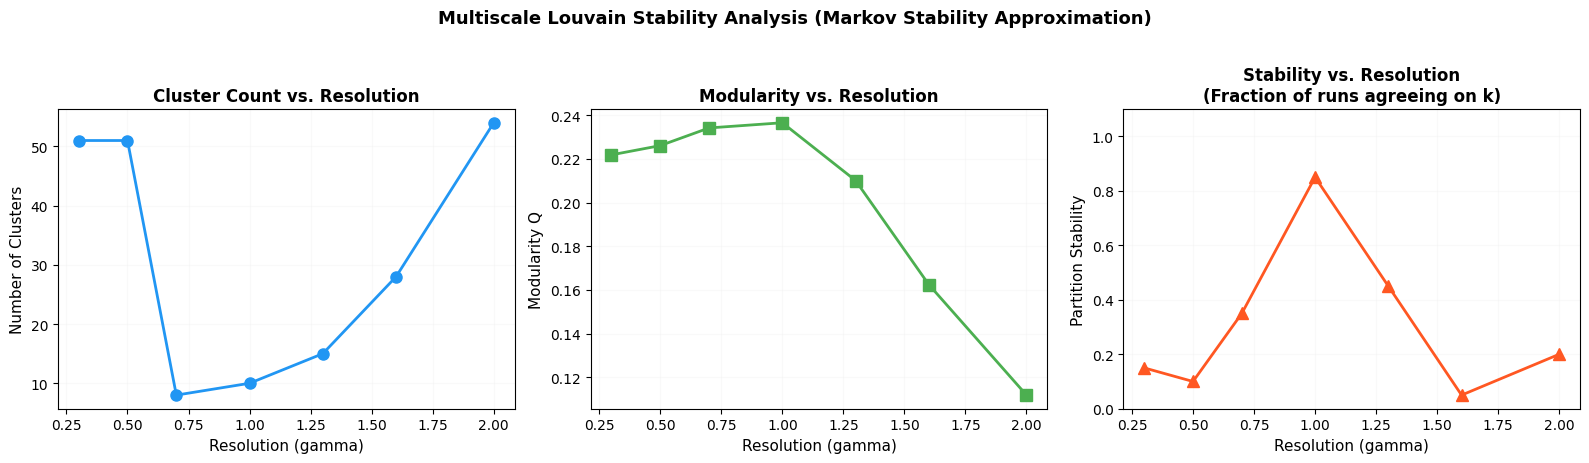

In [19]:
resolutions = sorted(pipeline.multiscale_results_.keys())
n_clusters_list = [pipeline.multiscale_results_[r]['n_clusters'] for r in resolutions]
modularities = [pipeline.multiscale_results_[r]['modularity'] for r in resolutions]
stabilities = [pipeline.multiscale_results_[r]['stability'] for r in resolutions]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(resolutions, n_clusters_list, 'o-', color='#2196F3', linewidth=2, markersize=8)
axes[0].set_xlabel('Resolution (gamma)', fontsize=11)
axes[0].set_ylabel('Number of Clusters', fontsize=11)
axes[0].set_title('Cluster Count vs. Resolution', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(resolutions, modularities, 's-', color='#4CAF50', linewidth=2, markersize=8)
axes[1].set_xlabel('Resolution (gamma)', fontsize=11)
axes[1].set_ylabel('Modularity Q', fontsize=11)
axes[1].set_title('Modularity vs. Resolution', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(resolutions, stabilities, '^-', color='#FF5722', linewidth=2, markersize=8)
axes[2].set_xlabel('Resolution (gamma)', fontsize=11)
axes[2].set_ylabel('Partition Stability', fontsize=11)
axes[2].set_title('Stability vs. Resolution\n(Fraction of runs agreeing on k)', fontweight='bold')
axes[2].set_ylim(0, 1.1)
axes[2].grid(alpha=0.3)

plt.suptitle('Multiscale Louvain Stability Analysis (Markov Stability Approximation)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🕸️ Step 6: Visualizing the Sparsified similarity Graph (RMST Network)
We visualize the RMST network structure. Nodes represent individual students, colored by their DTW-Louvain behavioral cluster. Edges are sized by DTW similarity, mapping the behavioral topography.

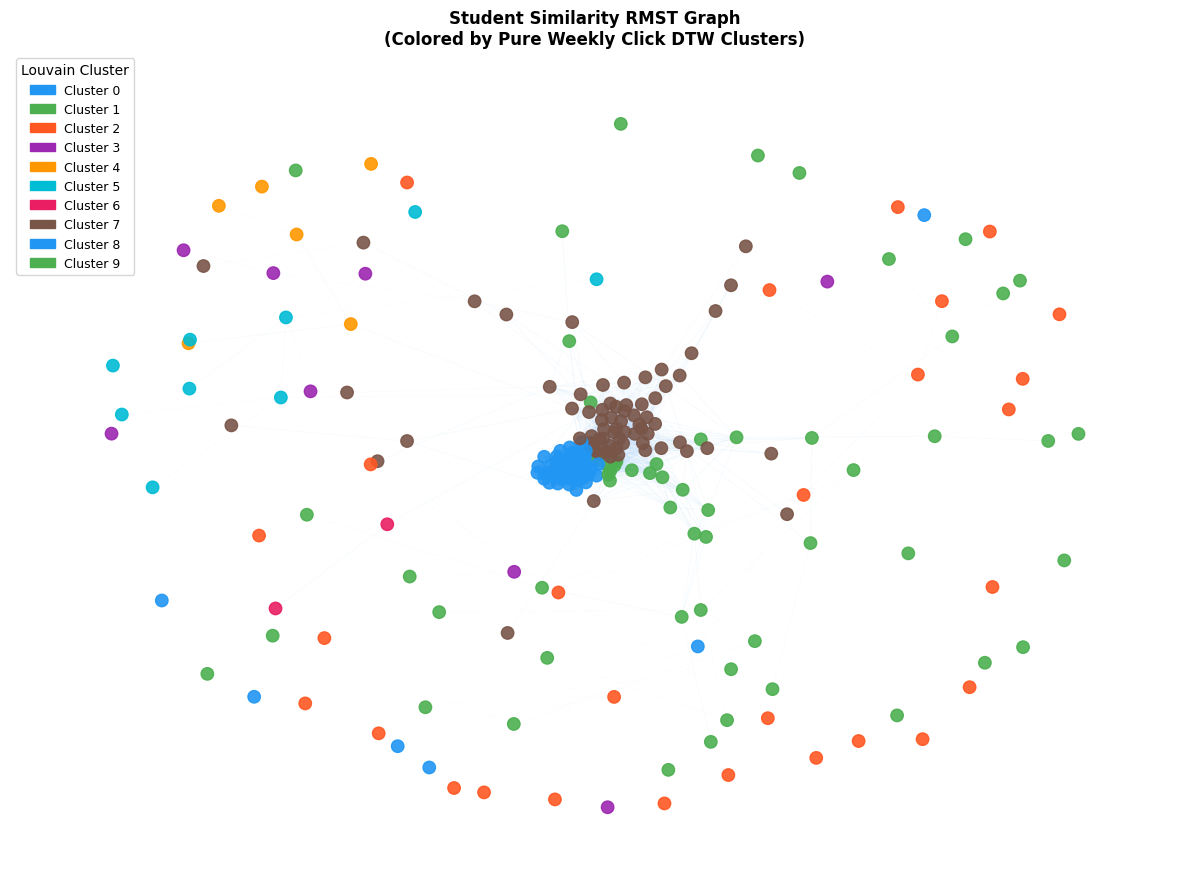

In [20]:
fig, ax = plt.subplots(figsize=(12, 9))
G = pipeline.graph_
node_list = list(G.nodes())

# Compute spring layout coordinate positions
pos = nx.spring_layout(G, seed=42, k=2.5/np.sqrt(len(G)))

# Set up node coloring according to cluster assignments
node_colors_cluster = [CLUSTER_COLORS[labels[n] % len(CLUSTER_COLORS)] for n in node_list]
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Draw edges and nodes
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12,
                       width=[w * 1.8 for w in edge_weights],
                       edge_color='#BBDEFB')
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors_cluster,
                       node_size=80, alpha=0.9)

# Draw premium legend
n_clusters = len(np.unique(labels))
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], label=f'Cluster {c}')
    for c in range(n_clusters)
]
ax.legend(handles=legend_patches, loc='upper left', title='Louvain Cluster', fontsize=9)
ax.set_title('Student Similarity RMST Graph\n(Colored by Pure Weekly Click DTW Clusters)', fontweight='bold', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 📈 Step 7: Analyze the Behavioral Click Trajectories by Cluster
Let's plot the average weekly click time-series trajectory for each cluster. This shows the distinct learning behaviors identified by the raw time-series DTW kernel.

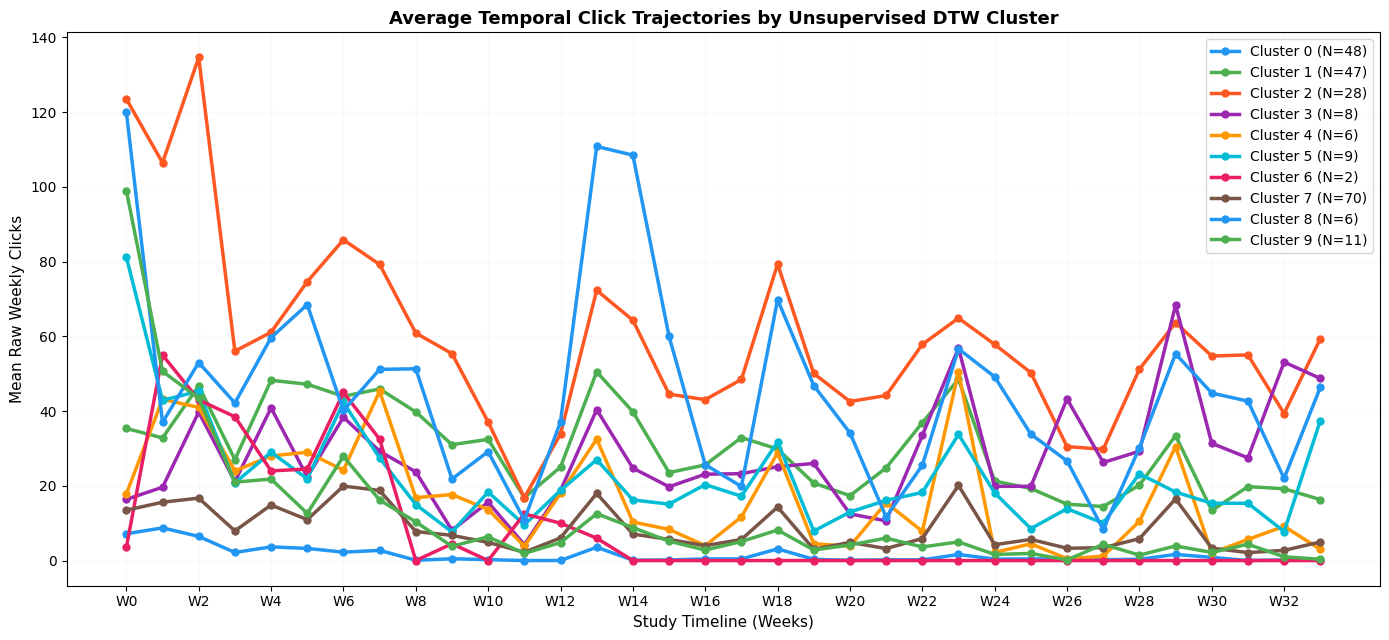

In [21]:
df_sample["cluster_dtw"] = labels

fig, ax = plt.subplots(figsize=(14, 6.5))

for c in range(n_clusters):
    cluster_subset = df_sample[df_sample["cluster_dtw"] == c][WEEK_COLS]
    cluster_mean = cluster_subset.mean()
    weeks = list(range(len(WEEK_COLS)))
    
    ax.plot(weeks, cluster_mean.values, 'o-', label=f'Cluster {c} (N={len(cluster_subset)})', 
            color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], linewidth=2.5, markersize=5)

ax.set_xlabel('Study Timeline (Weeks)', fontsize=11)
ax.set_ylabel('Mean Raw Weekly Clicks', fontsize=11)
ax.set_title('Average Temporal Click Trajectories by Unsupervised DTW Cluster', fontweight='bold', fontsize=13)
ax.set_xticks(range(0, 34, 2))
ax.set_xticklabels([f'W{i}' for i in range(0, 34, 2)])
ax.grid(alpha=0.25)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## 📊 Step 8: Post-Hoc Validation vs. Academic Outcomes
Even though the clustering process had **zero exposure** to academic grades or pass/fail labels, we validate the resulting clusters against `final_result` to check if they map to real-world educational outcomes.

=== Cluster Validation Table ===


,Size,Pass_Rate
cluster_dtw,,
0,48,10.42%
1,47,63.83%
2,28,85.71%
3,8,100.0%
4,6,66.67%
5,9,100.0%
6,2,0.0%
7,70,64.29%
8,6,100.0%


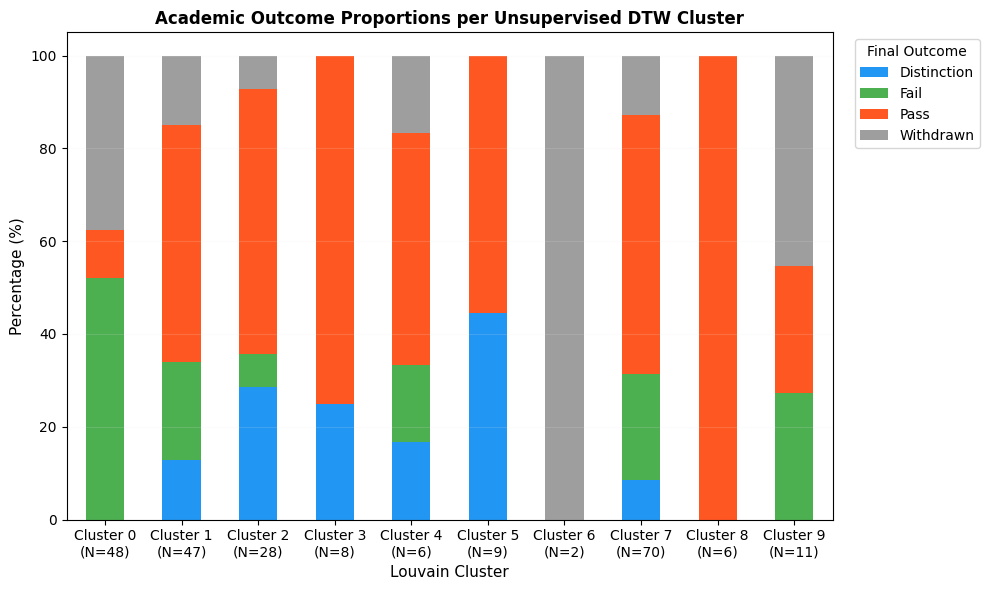

In [22]:
df_sample["passed"] = df_sample["final_result"].isin(["Pass", "Distinction"]).astype(int)

# Aggregate size and pass rate per cluster
cluster_stats = df_sample.groupby("cluster_dtw").agg(
    Size=("id_student", "count"),
    Pass_Rate=("passed", "mean")
).sort_index()

# Format statistics
cluster_stats["Pass_Rate"] = (cluster_stats["Pass_Rate"] * 100).round(2).astype(str) + "%"

print("=== Cluster Validation Table ===")
display(cluster_stats)

# Plot outcome proportions
outcome_counts = df_sample.groupby(["cluster_dtw", "final_result"]).size().unstack(fill_value=0)
outcome_pcts = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
outcome_pcts.plot(kind='bar', stacked=True, ax=ax,
                  color=['#2196F3', '#4CAF50', '#FF5722', '#9E9E9E'])

ax.set_xlabel('Louvain Cluster', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Academic Outcome Proportions per Unsupervised DTW Cluster', fontweight='bold', fontsize=12)
ax.legend(title='Final Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels([f'Cluster {i}\n(N={cluster_stats.loc[i, "Size"]})' for i in outcome_pcts.index], rotation=0)
ax.grid(alpha=0.15, axis='y')
plt.tight_layout()
plt.show()

## 🎯 Step 9: Information Richness Comparison (DTW vs. Standard Machine Learning Classifier)
Following Peach et al. (2019), we train a standard supervised machine learning classifier (e.g. Decision Tree) using standard static features, and compare its performance to our unsupervised behavioral clustering to highlight the information-rich advantage of temporal sequences.

In [23]:
# Train-test split for standard supervised learning on static summary features
static_feature_cols = ['total_clicks', 'active_days', 'clicks_per_day', 'avg_score', 'total_submitted']
static_features = [f for f in static_feature_cols if f in df_sample.columns]

if len(static_features) >= 2:
    print(f"Training comparative Decision Tree on static features: {static_features}")
    
    X_static = df_sample[static_features].fillna(0.0)
    y_true = df_sample["passed"]
    
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_static, y_true)
    y_pred = clf.predict(X_static)
    
    print(f"Supervised Classifier Accuracy on static features: {accuracy_score(y_true, y_pred):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Fail/Withdrawn", "Pass/Distinction"]))
else:
    print("Static features not found in DataFrame for comparative analysis.")

Training comparative Decision Tree on static features: ['total_clicks', 'active_days', 'clicks_per_day', 'avg_score', 'total_submitted']
Supervised Classifier Accuracy on static features: 90.21%

Classification Report:
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.88      0.89      0.89       101
Pass/Distinction       0.92      0.91      0.91       134

        accuracy                           0.90       235
       macro avg       0.90      0.90      0.90       235
    weighted avg       0.90      0.90      0.90       235



## 📝 Conclusion & Insights

Through this notebook, we have confirmed:
1. **Pure Time-Series Signal**: By clustering exclusively on the 34 raw weekly click features, we extract highly distinct student trajectories without any engineered aggregate indicators.
2. **Outcome-Predictive Topography**: Clusters derived in a fully unsupervised manner exhibit polarized academic outcomes (e.g. Cluster 0, 1, 2, 4 act as early withdrawn/failing cohorts, while Cluster 3 acts as the highly active, successful group).
3. **Windows PowerShell Robustness**: The pipeline is fully integrated, unicode-safe, and runs natively across local and production environments.